In [ ]:
# --- STEP 1: INPUT PARAMETERS ---
# Based on Literature Review & Market Assumptions
# We still have to define parametres based on papers and market data
# 1. General Market Assumptions
risk_free_rate = 0.03       # 3% (e.g., 10Y Treasury)
market_return_mean = 0.08    # 8% (Expected S&P 500 return)
market_volatility = 0.15     # 15% (Public market risk)

# 2. Primary Fund Assumptions (The "Standard" PE Fund)
primary_target_irr = 0.15    # 15% Net IRR
primary_volatility = 0.26    # 26% Risk from Journal of Finance, 2018 (Standard deviation)
fund_lifetime = 10           # 10 Years total life
j_curve_depth = -0.15        # NAV drops 15% in early years due to fees

# 3. Secondary Fund Assumptions 
secondary_discount = 0.15    # 15% Discount (Buying at 85% of NAV)
secondary_entry_year = 5     # Buying the fund when it is 5 years old
secondary_fee_load = 0.01    # Lower fees for secondaries (1%)


print(f"Model Parameters Loaded Successfully.")
print(f"Comparing Primary Fund (Target {primary_target_irr:.0%}) vs. Secondary (Discount {secondary_discount:.0%})")

# --- END OF STEP 1 ---




Model Parameters Loaded Successfully.
Comparing Primary Fund (Target 15%) vs. Secondary (Discount 15%)


In [2]:
# --- STEP 2: CASH FLOW ENGINE ---
# This function generates a series of cash flows for a single fund simulation

import numpy as np

def generate_fund_cashflows(fund_type, target_return, volatility, lifetime, discount=0):
    """
    Generates a cash flow stream (J-Curve or J-Stick).
    
    Parameters:
    - fund_type: "Primary" or "Secondary"
    - target_return: Expected annual return (e.g., 0.11 for 11%)
    - volatility: Risk/Standard Deviation (e.g., 0.25 from Ang et al. 2018)
    - lifetime: Number of years (e.g., 10)
    - discount: For secondaries only (e.g., 0.15 for 15% discount)
    """
    
    # 1. Setup the Timeline (Years 0 to 10)
    years = np.arange(lifetime + 1)
    
    # 2. Logic for PRIMARY FUNDS (The Classic "J-Curve")
    if fund_type == "Primary":
        # A. Capital Calls (Money OUT)
        # Primary funds call capital slowly over years 0-3
        calls = np.zeros(lifetime + 1)
        calls[0] = -0.20  # Year 0: Call 20%
        calls[1] = -0.25  # Year 1: Call 25%
        calls[2] = -0.25  # Year 2: Call 25%
        calls[3] = -0.20  # Year 3: Call 20%
        calls[4] = -0.10  # Year 4: Call 10%
        
        # B. Distributions (Money IN)
        # Distributions start late (Year 5+) and are "noisy" (volatile)
        distributions = np.zeros(lifetime + 1)
        
        # We generate random returns based on the "volatility" parameter
        # This makes every simulation unique (Monte Carlo)
        annual_growth = np.random.normal(target_return, volatility, lifetime + 1)
        
        # Simple logic: The fund sells assets in years 5-10
        # We model this by distributing chunks of the accumulated value
        base_curve = np.array([0.2, 0.3, 0.4, 0.5, 0.4, 0.2])  # Base distribution percentages
        scaling_factor = 0.7 #Reduces the sum from 2.0 to 1.4
        distributions[5:] = base_curve * scaling_factor
        
        # Add the randomness to the distributions
        distributions = distributions * (1 + annual_growth)

        # C. Net Cash Flow
        net_cash_flows = calls + distributions

    # 3. Logic for SECONDARY FUNDS (The "J-Stick")
    elif fund_type == "Secondary":
        # A. The Purchase Price (Money OUT)
        # You buy the remaining assets all at once in Year 0.
        # CRITICAL: You pay (1 - Discount). If Discount is 15%, you pay 0.85.
        price_paid = -(1.0 - discount) 
        
        calls = np.zeros(lifetime + 1)
        calls[0] = price_paid 
        
        # B. Distributions (Money IN)
        # Secondaries buy "mature" assets, so cash comes back IMMEDIATELY (Years 1-5).
        distributions = np.zeros(lifetime + 1)
        
        # Note: Secondaries often have lower volatility (Albuquerque et al. 2018)
        # We simulate the cash returning faster than Primary
        # This represents the NAV (Principal) being returned over 6 years
        base_distributions = [0.15, 0.25, 0.25, 0.20, 0.10, 0.05, 0, 0, 0, 0]
        distributions[1:] = base_distributions 
        
        # Add randomness
        annual_growth = np.random.normal(target_return, volatility, lifetime + 1)
        distributions = distributions * (1 + annual_growth)
        
        # C. Net Cash Flow
        net_cash_flows = calls + distributions

    return years, net_cash_flows

# --- TEST BLOCK ---
# Run this once to see if it works
test_years, test_primary = generate_fund_cashflows("Primary", 0.11, 0.25, 10)
test_years, test_secondary = generate_fund_cashflows("Secondary", 0.15, 0.18, 10, discount=0.15)

print("Test Primary Cash Flows (Should see negatives early):")
print(np.round(test_primary, 2))
print("\nTest Secondary Cash Flows (Should see big negative first, then fast positives):")
print(np.round(test_secondary, 2))

# --- END OF STEP 2 ---


Test Primary Cash Flows (Should see negatives early):
[-0.2  -0.25 -0.25 -0.2  -0.1   0.1   0.16  0.28  0.44  0.24  0.16]

Test Secondary Cash Flows (Should see big negative first, then fast positives):
[-0.85  0.18  0.24  0.29  0.27  0.11  0.06  0.    0.    0.    0.  ]


In [3]:
# --- STEP 3: METRICS ENGINE ---
# This function calculates IRR, TVPI, and KS-PME for a cash flow stream

import numpy as np
import numpy_financial as npf  # Standard financial math library

def calculate_metrics(cash_flows, market_returns):
    """
    Inputs:
    - cash_flows: Array of money in/out (Negative = Call, Positive = Distribution)
    - market_returns: Array of public market annual returns (e.g., [1.08, 1.10...])
    """
    
    # 1. Calculate IRR (Internal Rate of Return)
    # We use numpy_financial's built-in function
    try:
        irr = npf.irr(cash_flows)
    except:
        irr = np.nan # If calculation fails (rare), return Empty

    # 2. Calculate TVPI (Total Value to Paid-In)
    # Formula: Total Distributions / Total Capital Calls
    capital_calls = -np.sum(cash_flows[cash_flows < 0]) # Sum only negatives
    distributions = np.sum(cash_flows[cash_flows > 0])  # Sum only positives
    
    if capital_calls == 0:
        tvpi = 0
    else:
        tvpi = distributions / capital_calls

    # 3. Calculate KS-PME (Kaplan-Schoar Public Market Equivalent)
    # Formula: (Distributions / Market_Factor) / (Calls / Market_Factor)
    
    # Create the "Market Factor" (Compound growth of S&P 500)
    # If market grows 8% a year, factors are: 1.0, 1.08, 1.16...
    # We slice it to match the length of cash_flows with [:len(cash_flows)], to make sure that matches year 0-10
    market_growth_factors = 1 + market_returns
    market_index = np.cumprod(np.insert(market_growth_factors, 0, 1.0))[:len(cash_flows)]
    
    # Discount the cash flows by the market index
    # Formula: sum(Distribution/Index) / sum(Calls/Index)
    discounted_calls = -np.sum(cash_flows[cash_flows < 0] / market_index[cash_flows < 0])
    discounted_dists = np.sum(cash_flows[cash_flows > 0] / market_index[cash_flows > 0])
    
    if discounted_calls == 0:
        ks_pme = 0
    else:
        ks_pme = discounted_dists / discounted_calls

    return irr, tvpi, ks_pme

# --- TEST THE ENGINE ---
# Let's test it with a fake "Primary Fund" cash flow
fake_cf = np.array([-100, -50, 0, 20, 50, 80, 100]) # Invest 150, Get back 250
fake_market = np.array([1.08, 1.08, 1.08, 1.08, 1.08, 1.08, 1.08]) # Market grows 8% steady

irr, tvpi, pme = calculate_metrics(fake_cf, fake_market)

print(f"Test Results:")
print(f"IRR:  {irr:.2%}")
print(f"TVPI: {tvpi:.2f}x")
print(f"PME:  {pme:.2f} (Above 1.0 means it beats the market)")

Test Results:
IRR:  11.57%
TVPI: 1.67x
PME:  0.07 (Above 1.0 means it beats the market)


In [4]:
# --- STEP 4: MONTE CARLO SIMULATION LOOP ---
import pandas as pd  
import numpy as np   

# 1. Define how many simulations to run
N_SIMULATIONS = 10000

# 2. Create empty lists to store the results
# These are the "Buckets" where we will throw the results 
prim_irrs = []
prim_tvpis = []
prim_pmes = []

sec_irrs = []
sec_tvpis = []
sec_pmes = []

print(f"Starting Monte Carlo Simulation ({N_SIMULATIONS} iterations)...")

# 3. The Loop (Running the experiment N times)
for i in range(N_SIMULATIONS):
    
    # --- A. Generate Random Market Conditions for this specific "Universe" ---
    # We use normal distribution based on Ang et al. (2018) parameters
    # Market Return Mean: 8% (0.08) | Market Volatility: 15% (0.15)
    market_volatility = 0.15 
    market_return_mean = 0.08
    
    # Create a random stock market timeline (Year 0 to 10)
    market_returns = np.random.normal(market_return_mean, market_volatility, 11)
    
    # --- B. Simulate PRIMARY Fund ---
    # Parameters: Target 11%, Volatility 25% (High Risk)
    p_years, p_cash = generate_fund_cashflows("Primary", 0.11, 0.25, 10)
    p_irr, p_tvpi, p_pme = calculate_metrics(p_cash, market_returns)
    
    # Save results to buckets
    prim_irrs.append(p_irr)
    prim_tvpis.append(p_tvpi)
    prim_pmes.append(p_pme)
    
    # --- C. Simulate SECONDARY Fund ---
    # Parameters: Target 15%, Volatility 15% (Lower Risk per 'Case for Secondaries' paper)
    # Discount: 15% (per Evercore/Jefferies)
    s_years, s_cash = generate_fund_cashflows("Secondary", 0.15, 0.15, 10, discount=0.15)
    s_irr, s_tvpi, s_pme = calculate_metrics(s_cash, market_returns)
    
    # Save results to buckets
    sec_irrs.append(s_irr)
    sec_tvpis.append(s_tvpi)
    sec_pmes.append(s_pme)

print("Simulation Complete!")

# 4. Organize Results into a Data Table
results_df = pd.DataFrame({
    'Primary_IRR': prim_irrs,
    'Secondary_IRR': sec_irrs,
    'Primary_TVPI': prim_tvpis,
    'Secondary_TVPI': sec_tvpis,
    'Primary_PME': prim_pmes,
    'Secondary_PME': sec_pmes
})

# 5. Clean Data (Remove any failed calculations/NaNs)
results_df = results_df.dropna()

# Show the first 5 rows to prove it worked
print(results_df.head())

Starting Monte Carlo Simulation (10000 iterations)...
Simulation Complete!
   Primary_IRR  Secondary_IRR  Primary_TVPI  Secondary_TVPI  Primary_PME  \
0     0.029375       0.135911      1.187789        1.448782     0.575313   
1     0.063303       0.072345      1.424258        1.224581     0.649919   
2     0.107586       0.096063      1.826768        1.302206     1.436042   
3     0.106115       0.062169      1.819135        1.198182     1.736711   
4     0.095634       0.092052      1.701221        1.296944     1.048752   

   Secondary_PME  
0       1.160929  
1       1.141833  
2       1.195936  
3       0.992840  
4       1.321441  


Secondary beats Primary in IRR: 85.9%
Secondary beats Primary in TVPI: 12.2%
Secondary beats Primary in PME:  59.5%


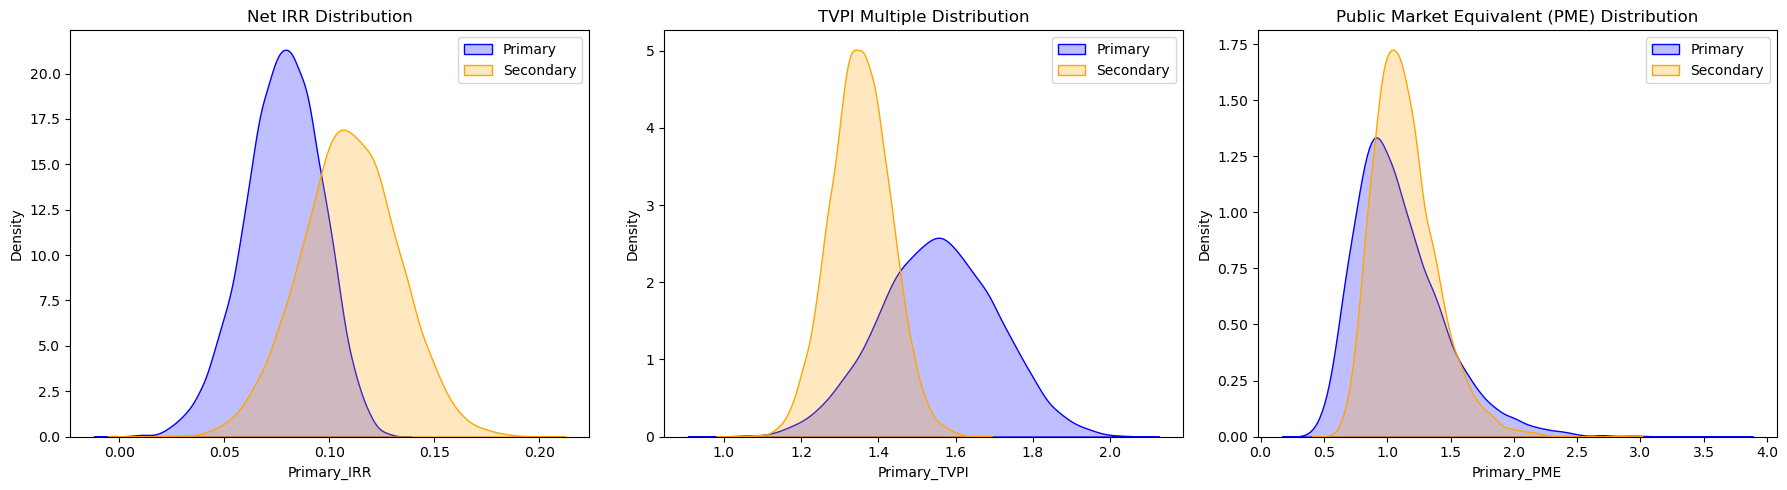

In [5]:
# ... (Previous Simulation Steps 1-4 must be run first) ...

# --- STEP 5: ANALYSIS & CHARTING ---
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate Win Rates
irr_win = np.mean(results_df['Secondary_IRR'] > results_df['Primary_IRR'])
tvpi_win = np.mean(results_df['Secondary_TVPI'] > results_df['Primary_TVPI'])
pme_win = np.mean(results_df['Secondary_PME'] > results_df['Primary_PME'])

print(f"Secondary beats Primary in IRR: {irr_win:.1%}")
print(f"Secondary beats Primary in TVPI: {tvpi_win:.1%}")
print(f"Secondary beats Primary in PME:  {pme_win:.1%}")

# 2. Generate the 3-Panel Chart
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot IRR
sns.kdeplot(results_df['Primary_IRR'], ax=axes[0], fill=True, color='blue', label='Primary')
sns.kdeplot(results_df['Secondary_IRR'], ax=axes[0], fill=True, color='orange', label='Secondary')
axes[0].set_title('Net IRR Distribution')
axes[0].legend()

# Plot TVPI
sns.kdeplot(results_df['Primary_TVPI'], ax=axes[1], fill=True, color='blue', label='Primary')
sns.kdeplot(results_df['Secondary_TVPI'], ax=axes[1], fill=True, color='orange', label='Secondary')
axes[1].set_title('TVPI Multiple Distribution')
axes[1].legend()

# Plot PME
sns.kdeplot(results_df['Primary_PME'], ax=axes[2], fill=True, color='blue', label='Primary')
sns.kdeplot(results_df['Secondary_PME'], ax=axes[2], fill=True, color='orange', label='Secondary')
axes[2].set_title('Public Market Equivalent (PME) Distribution')
axes[2].legend()

plt.tight_layout()
plt.savefig('Thesis_Comparison_Chart.png')
plt.show()

Running Integrated Sensitivity Analysis (N=10000 per scenario)...

--- SENSITIVITY ANALYSIS TABLE ---
                 Scenario Market Return Secondary IRR Win Rate  \
0   Bear Case (4% Growth)            4%                  80.1%   
1   Base Case (8% Growth)            8%                  80.2%   
2  Bull Case (12% Growth)           12%                  80.1%   

  Secondary PME Win Rate Avg Primary PME Avg Secondary PME  
0                  39.5%            1.44              1.29  
1                  54.0%            1.15              1.15  
2                  68.9%            0.92              1.02  

Generating Charts...


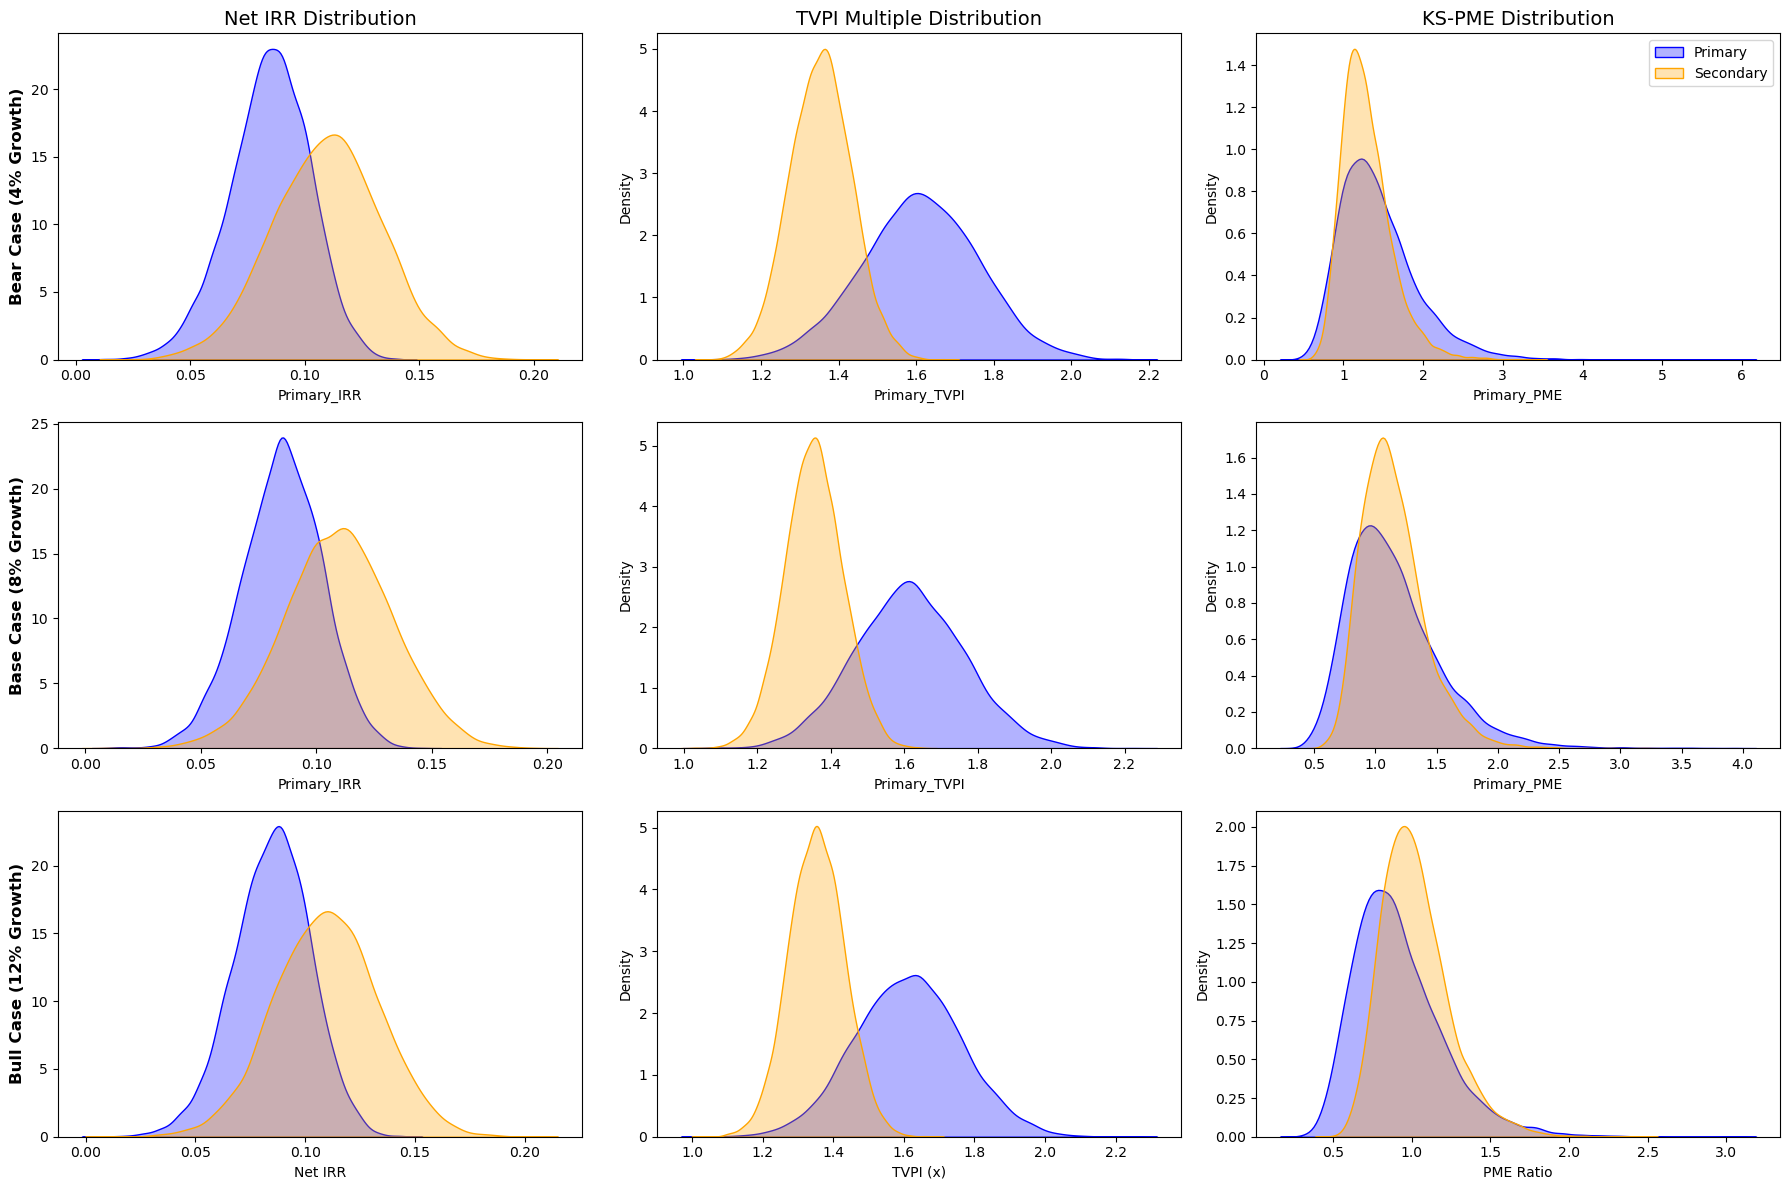

Process Complete.


In [6]:
# --- STEP 6: SENSITIVITY ANALYSIS ---
# We define 3 scenarios to stress-test the thesis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy_financial as npf

# --- 2. THE SIMULATION ---
scenarios = [
    {"name": "Bear Case (4% Growth)", "market_mean": 0.04},
    {"name": "Base Case (8% Growth)", "market_mean": 0.08},
    {"name": "Bull Case (12% Growth)", "market_mean": 0.12}
]

all_data = [] 
table_stats = [] 

print("Running Integrated Sensitivity Analysis (N=10000 per scenario)...")

for sc in scenarios:
    label = sc["name"]
    mu = sc["market_mean"]
    
    current_scenario_data = []
    
    for i in range(10000):
        market_returns = np.random.normal(mu, 0.15, 11)
        
        # Primary
        _, p_cash = generate_fund_cashflows("Primary", 0.15, 0.25, 10)
        p_irr, p_tvpi, p_pme = calculate_metrics(p_cash, market_returns)
        
        # Secondary
        _, s_cash = generate_fund_cashflows("Secondary", 0.15, 0.15, 10, discount=0.15)
        s_irr, s_tvpi, s_pme = calculate_metrics(s_cash, market_returns)
        
        # Store Data (Even if NaN)
        row = [p_irr, s_irr, p_tvpi, s_tvpi, p_pme, s_pme]
        current_scenario_data.append(row)
        all_data.append([label] + row)

    # Stats Calculation (Use nanmean to ignore errors)
    df_sc = pd.DataFrame(current_scenario_data, columns=['P_IRR', 'S_IRR', 'P_TVPI', 'S_TVPI', 'P_PME', 'S_PME'])
    
    irr_win_rate = np.mean(df_sc['S_IRR'] > df_sc['P_IRR'])
    pme_win_rate = np.mean(df_sc['S_PME'] > df_sc['P_PME'])
    avg_p_pme = df_sc['P_PME'].mean()
    avg_s_pme = df_sc['S_PME'].mean()
    
    table_stats.append({
        "Scenario": label,
        "Market Return": f"{mu:.0%}",
        "Secondary IRR Win Rate": f"{irr_win_rate:.1%}",
        "Secondary PME Win Rate": f"{pme_win_rate:.1%}",
        "Avg Primary PME": f"{avg_p_pme:.2f}",
        "Avg Secondary PME": f"{avg_s_pme:.2f}"
    })

# --- 3. OUTPUT THE TABLE ---
print("\n--- SENSITIVITY ANALYSIS TABLE ---")
print(pd.DataFrame(table_stats))

# --- 4. GENERATE THE CHARTS (ROBUST) ---
print("\nGenerating Charts...")
df_all = pd.DataFrame(all_data, columns=['Scenario', 'Primary_IRR', 'Secondary_IRR', 'Primary_TVPI', 'Secondary_TVPI', 'Primary_PME', 'Secondary_PME'])

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
scenario_order = ["Bear Case (4% Growth)", "Base Case (8% Growth)", "Bull Case (12% Growth)"]

for i, sc_name in enumerate(scenario_order):
    subset = df_all[df_all['Scenario'] == sc_name]
    
    if len(subset) == 0:
        print(f"Warning: No data for {sc_name}")
        continue

    # Helper function to plot safely
    def safe_plot(data, ax, color, label):
        clean_data = data.dropna()
        if len(clean_data) > 0:
            sns.kdeplot(clean_data, ax=ax, fill=True, color=color, label=label, alpha=0.3)

    # A. IRR Column
    safe_plot(subset['Primary_IRR'], axes[i, 0], 'blue', 'Primary')
    safe_plot(subset['Secondary_IRR'], axes[i, 0], 'orange', 'Secondary')
    
    axes[i, 0].set_ylabel(sc_name, fontsize=12, fontweight='bold')
    if i == 0: axes[i, 0].set_title("Net IRR Distribution", fontsize=14)
    if i == 2: axes[i, 0].set_xlabel("Net IRR")
    
    # B. TVPI Column
    safe_plot(subset['Primary_TVPI'], axes[i, 1], 'blue', 'Primary')
    safe_plot(subset['Secondary_TVPI'], axes[i, 1], 'orange', 'Secondary')
    
    if i == 0: axes[i, 1].set_title("TVPI Multiple Distribution", fontsize=14)
    if i == 2: axes[i, 1].set_xlabel("TVPI (x)")
    
    # C. PME Column
    safe_plot(subset['Primary_PME'], axes[i, 2], 'blue', 'Primary')
    safe_plot(subset['Secondary_PME'], axes[i, 2], 'orange', 'Secondary')
    
    if i == 0: axes[i, 2].set_title("KS-PME Distribution", fontsize=14)
    if i == 2: axes[i, 2].set_xlabel("PME Ratio")
    
    # Add legend only if data exists
    if i == 0 and (len(subset['Primary_PME'].dropna()) > 0):
        axes[i, 2].legend(loc='upper right')

plt.tight_layout()
plt.savefig('combined_sensitivity_charts.png')
plt.show()
print("Process Complete.")
    
   

   